### 이상치 데이터
* 이상치
    - IQR의 1.5배 또는 3배의 차이가 나면 이상치라고 표현한다
    - 다른 데이터보다 아주 작거나 큰 값을 말한다
    - 데이터를 분석할 때 이상치는 의사결정에 영향을 미칠 수 있다.
* 이상치 처리
    1. 제거
        - 오타, 오류, 비상식적 값들은 단순히 제거한다
    2. 치환
        - 평균, 최빈값, 중앙값(중위수)
* 이상치 구하기
    - 1/4 분위값 25%, 2/4 분위값 중앙값(median), 3/4 분위값 75%
    - IQR = Q3(3사분위) - Q1(1사분위)
    - 최대 이상치 = Q3(3사분위) + IQR * 1.5(3.0)
    - 최저 이상치 = Q1(1사분위) - IQR * 1.5(3.0)
---

<img src="../../images/이상치.png" width="300" height="300">

In [1]:
import pandas as pd
df = pd.read_csv("../../data_set/2.데이터 클린징/food.csv")
df

,food_a,food_b,food_c
0,20,5,5
1,21,6,5
2,23,11,5
3,22,13,12
4,26,15,10
5,120,16,11
6,35,20,20
7,35,20,20
8,41,21,350
9,42,23,20


In [2]:
df.mean()

food_a    47.407407
food_b    51.037037
food_c    42.407407
dtype: float64

In [3]:
df.describe()

,food_a,food_b,food_c
count,27.000000,27.000000,27.000000
mean,47.407407,51.037037,42.407407
std,20.267935,110.789295,64.268822
min,20.000000,5.000000,5.000000
25%,38.000000,20.000000,20.000000
50%,46.000000,30.000000,31.000000
75%,57.000000,41.500000,45.500000
max,120.000000,600.000000,350.000000


In [6]:
import numpy as np
food_a_madian = np.median( df['food_a'])
food_b_madian = np.median( df['food_b'])
food_c_madian = np.median( df['food_c'])

print(food_a_madian)
print(food_b_madian)
print(food_c_madian)

46.0
30.0
31.0


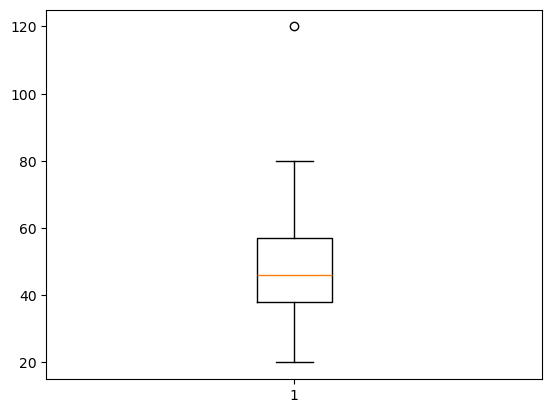

In [7]:
import matplotlib.pyplot as plt
plt.boxplot(df['food_a'])
plt.show()

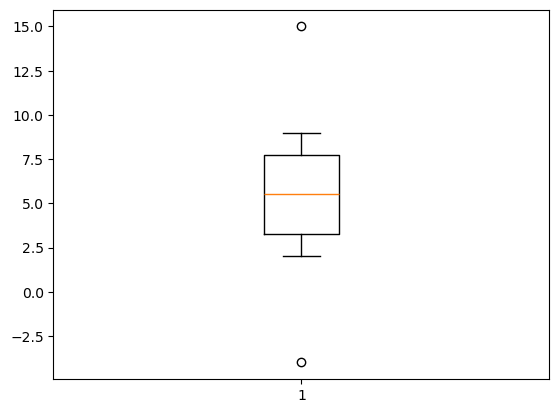

In [39]:
test_median = [-4, 2, 3, 4, 5, 6, 7, 8, 9, 15]
df_test = pd.DataFrame(test_median)
plt.boxplot( df_test[0])
plt.show()

In [40]:
df_test.describe()

,0
count,10.000000
mean,5.500000
std,4.972145
min,-4.000000
25%,3.250000
50%,5.500000
75%,7.750000
max,15.000000


In [41]:
q1 = df_test.describe().loc["25%"][0]
q3 = df_test.describe().loc["75%"][0]
q1, q3

(np.float64(3.25), np.float64(7.75))

In [42]:
iqr = q3 - q1
print(iqr)
lowerfence = q1 - iqr * 1.5 #최저 이상치
upperfence = q3 + iqr * 1.5 #최대 이상치
lowerfence, upperfence

4.5


(np.float64(-3.5), np.float64(14.5))

In [43]:
df_test[0] < lowerfence

0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: 0, dtype: bool

In [46]:
print(df_test[0])
print((df_test[0] < lowerfence) | (df_test[0] > upperfence))

df_test[ (df_test[0] < lowerfence) | (df_test[0] > upperfence) ]

0    -4
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    15
Name: 0, dtype: int64
0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9     True
Name: 0, dtype: bool


,0
0,-4
9,15


0    False
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9    False
Name: 0, dtype: bool
   0
1  2
2  3
3  4
4  5
5  6
6  7
7  8
8  9


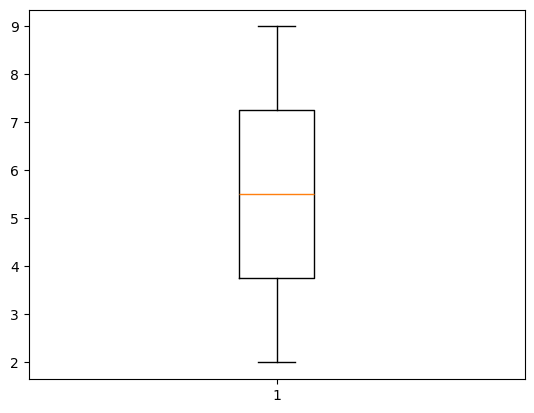

In [47]:
print((df_test[0] >= lowerfence) & (df_test[0] <= upperfence))

print(df_test[ (df_test[0] >= lowerfence) & (df_test[0] <= upperfence) ])

df_test = df_test[ (df_test[0] >= lowerfence) & (df_test[0] <= upperfence) ]

plt.boxplot(df_test)
plt.show()

In [48]:
df_test

,0
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9


In [49]:
df_test.reset_index(drop=True)

,0
0,2
1,3
2,4
3,5
4,6
5,7
6,8
7,9


In [25]:
df_test = pd.DataFrame( test_median, columns=['data'])
df_test

,data
0,-4
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,15


In [29]:
print((df_test['data'] < lowerfence) | (df_test['data'] > upperfence))
mask = (df_test['data'] < lowerfence) | (df_test['data'] > upperfence)

0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9     True
Name: data, dtype: bool


In [30]:
median = df_test['data'].median()
median

5.5

In [35]:
df_test.dtypes

data    int64
dtype: object

In [36]:
df_test['data'] = df_test['data'].astype('float64')
df_test

,data
0,-4.0
1,2.0
2,3.0
3,4.0
4,5.0
5,6.0
6,7.0
7,8.0
8,9.0
9,15.0


In [37]:
df_test.loc[mask,'data'] = median
df_test

,data
0,5.5
1,2.0
2,3.0
3,4.0
4,5.0
5,6.0
6,7.0
7,8.0
8,9.0
9,5.5


In [38]:
df_test = pd.DataFrame( test_median, columns=['data'])
df_test

,data
0,-4
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,15
